Develop a program to implement the Naive Bayesian classifier considering Olivetti Face dataset for training. Compute the accuracy of the classifier, considering a few test examples.

In [1]:
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
X, y = fetch_olivetti_faces(shuffle=True, random_state=42, return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42)

gnb = GaussianNB().fit(Xtr, ytr)
pred = gnb.predict(Xte)

In [3]:
print(f"Accuracy: {accuracy_score(yte, pred)*100:.2f}%\n")
print(f"Classification Report:\n{classification_report(yte, pred, zero_division=1)}")
print(f"Confusion Matrix:\n{confusion_matrix(yte, pred)}\n")
print(f"Cross-validation Accuracy: {cross_val_score(gnb, X, y, cv=5).mean()*100:.2f}%")

Accuracy: 80.83%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         2
           2       0.33      0.67      0.44         3
           3       1.00      0.00      0.00         5
           4       1.00      0.50      0.67         4
           5       1.00      1.00      1.00         2
           7       1.00      0.75      0.86         4
           8       1.00      0.67      0.80         3
           9       1.00      0.75      0.86         4
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         1
          12       0.40      1.00      0.57         4
          13       1.00      0.80      0.89         5
          14       1.00      0.40      0.57         5
          15       0.67      1.00      0.80         2
          16       1.00      0.67      0.80         3
          17       1.00      1.00      1

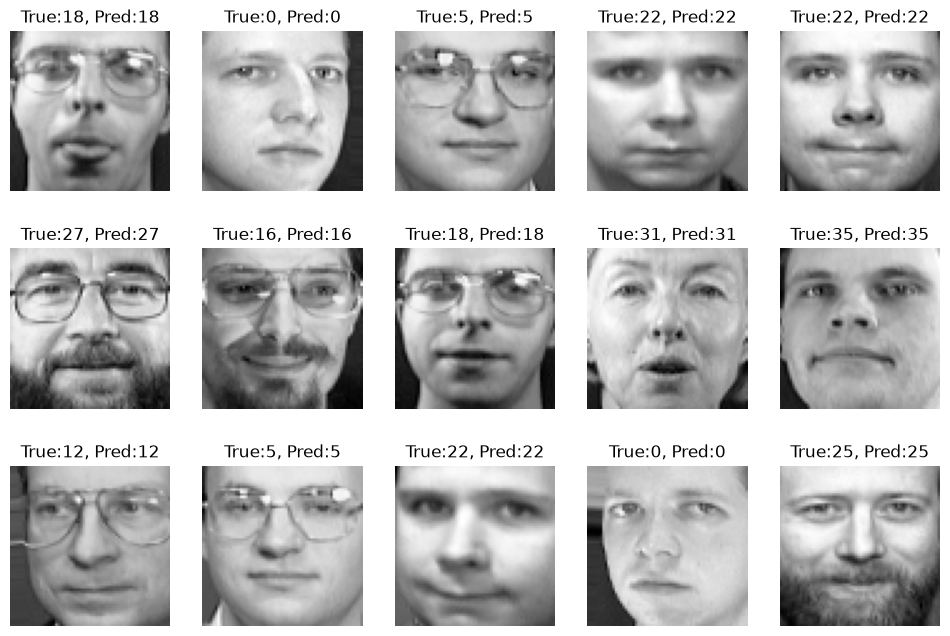

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for a, img, t, p in zip(axes.ravel(), Xte, yte, pred):
    a.imshow(img.reshape(64, 64), cmap="gray")
    a.set_title(f"True:{t}, Pred:{p}")
    a.axis("off")

plt.show()